# IID Gaussian disorder on the full diagonal
For the existing $20\times32$ hard-wall parent Hamiltonian, add
$$\hat H_{\rm dis}=\hat H_{\rm flat}-\sum_{x,y,\mu}v_{x,y,\mu}\hat c^\dagger_{x,y,\mu}\hat c_{x,y,\mu},$$
where $v_{x,y,\mu}$ are independent real Gaussian variables with population mean zero and variance $W^2=0.01,0.04,0.16$. Every diagonal entry has an independent potential, including the two orbitals at the same cell. A realization's spatial sample mean is not artificially subtracted. Each strength has 100 independent, deterministic-seeded realizations, independent also across strengths. Fill the lowest 640 levels globally for each realization; no additional spectral flattening is applied after adding the potential.

The subsystem has all x, both orbitals, and $y=0,\ldots,15$ (640 modes); use the fixed cut $y_0=0$. Diagonalize its centered covariance separately for every ground state and retain $|\lambda|\le0.99$.
$$\varepsilon=\log[(1-\lambda)/(1+\lambda)],\qquad |\varepsilon|\le\log199.$$
The main figure shows raw pooled histogram counts. A second figure shows unit-area densities including the clean reference. Both use identical, zero-centered bins. These are static pure ground states, with no circuit dynamics. The active/exterior block reduction is exact for the hard-wall Hamiltonian and was checked against a full-space calculation for one disordered realization.

In [1]:
import os
CPU_RANGE=(8,15) # Editable inclusive allocation.
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for k in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[k]=str(len(selected))
print('Allocated CPUs:',selected)

Allocated CPUs: [8, 9, 10, 11, 12, 13, 14, 15]


## Acquisition and configuration
The companion runner constructs the parent with the canonical CPU class, then solves each static ground state. Existing realization receipts allow a completed run to be reused.

In [2]:
from pathlib import Path
import sys,json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd()
RUN_ACQUISITION=False # Set True to generate/revalidate realization products.
if RUN_ACQUISITION:
    subprocess.run([sys.executable,str(OUT/'run_analysis.py')],check=True)
complete=json.loads((OUT/'acquisition_complete.json').read_text())
assert complete['status']=='complete' and complete['realizations']==300
config=complete['configuration']
display(pd.Series(config))
VARIANCES=config['variances']
L=config['L'];E=float(np.log1p(L)-np.log1p(-L))
def sha(p):
    with p.open('rb') as f:return hashlib.file_digest(f,'sha256').hexdigest()


Nx                                                                       20
Ny                                                                       32
walls                                                               [5, 15]
alpha_1                                                                   1
alpha_2                                                                  30
nshell                                                                    1
variances                                                [0.01, 0.04, 0.16]
samples_per_variance                                                    100
seed                                                             2026092701
L                                                                      0.99
disorder                  iid Gaussian potentials on all 1280 diagonal e...
mean                                                                    0.0
sample_mean_subtracted                                                False
hamiltonian 

## Validate and collect the spectra
Each realization is verified against its checksum and configuration identity. Save the unmodified centered spectra and the finite-window energies with realization labels.

In [3]:
spectra={};energy={};cache={};rows=[];sample_rows=[];receipts=[]
for vi,variance in enumerate(VARIANCES):
    arrays=[];potentials=[];eigensystems=[]
    for s in tqdm(range(100),desc=f'Validate variance {variance:g}',unit='state'):
        f=OUT/'realizations'/f'variance_{vi:02}_sample_{s:03}.npz'
        d=json.loads(f.with_suffix('.json').read_text())
        assert d['identity']==complete['identity'] and d['sample_id']==s and d['variance']==variance
        assert d['bytes']==f.stat().st_size and d['sha256']==sha(f)
        receipts.append(d)
        with np.load(f) as z:
            assert int(z['sample_id'])==s and float(z['variance'])==variance
            arrays.append(z['centered_eigenvalues'])
            potentials.append(z['diagonal_potential'])
            eigensystems.append(z['hamiltonian_energies'])
    lam=np.array(arrays);v=np.array(potentials)
    assert lam.shape==(100,640) and v.shape==(100,1280)
    assert np.isfinite(v).all() and np.all(v!=0)
    assert np.all(v[:,0::2]!=v[:,1::2])
    assert np.isfinite(lam).all() and np.max(np.abs(lam))<=1+1e-8
    mask=np.abs(lam)<=L
    sample_id,mode_index=np.nonzero(mask)
    eps=np.log1p(-lam[mask])-np.log1p(lam[mask])
    assert np.isfinite(eps).all() and np.max(np.abs(eps))<=E
    assert np.allclose(-np.tanh(eps/2),lam[mask],rtol=0,atol=5e-16)
    spectra[variance]=lam;energy[variance]=eps
    cache[f'centered_spectra_{vi}']=lam;cache[f'energy_{vi}']=eps
    cache[f'sample_id_{vi}']=sample_id;cache[f'mode_index_{vi}']=mode_index
    cache[f'diagonal_potential_{vi}']=v;cache[f'hamiltonian_energies_{vi}']=np.array(eigensystems)
    n=np.bincount(sample_id,minlength=100)
    m1=np.bincount(sample_id,weights=eps,minlength=100)
    m2=np.bincount(sample_id,weights=eps**2,minlength=100)
    N=len(eps)
    leave=(m2.sum()-m2)/(N-n)-((m1.sum()-m1)/(N-n))**2
    se=float(np.sqrt(99/100*np.sum((leave-leave.mean())**2)))
    rows.append({'disorder_variance':variance,'disorder_std':np.sqrt(variance),'samples':100,
                 'retained_modes':N,'mean_retained_per_state':float(n.mean()),
                 'energy_mean':float(eps.mean()),'energy_variance':float(eps.var()),
                 'variance_jackknife_se':se,'realized_potential_mean':float(v.mean()),
                 'realized_potential_variance':float(v.var())})
    for s in range(100):
        sample_rows.append({'disorder_variance':variance,'sample_id':s,'retained_modes':int(n[s]),
                            'energy_sum':float(m1[s]),'energy_square_sum':float(m2[s])})
with np.load(OUT/'clean_reference.npz') as z:
    clean=z['centered_eigenvalues'];m=np.abs(clean)<=L
    clean_energy=np.log1p(-clean[m])-np.log1p(clean[m])
np.savez_compressed(OUT/'spectra_and_energies.npz',**cache,variances=VARIANCES,L=L,clean_energy=clean_energy)
summary=pd.DataFrame(rows)
summary.to_csv(OUT/'summary.csv',index=False)
pd.DataFrame(sample_rows).to_csv(OUT/'sample_moments.csv',index=False)
display(summary)

Validate variance 0.01:   0%|          | 0/100 [00:00<?, ?state/s]

Validate variance 0.04:   0%|          | 0/100 [00:00<?, ?state/s]

Validate variance 0.16:   0%|          | 0/100 [00:00<?, ?state/s]

,disorder_variance,disorder_std,samples,retained_modes,mean_retained_per_state,energy_mean,energy_variance,variance_jackknife_se,realized_potential_mean,realized_potential_variance
0,0.01,0.1,100,3000,30.00,-0.002565,9.623847,0.004255,-0.000413,0.010051
1,0.04,0.2,100,3000,30.00,0.000005,9.638875,0.008120,-0.000152,0.039839
2,0.16,0.4,100,3004,30.04,0.003184,9.648085,0.017115,0.000101,0.160424


## Raw-count entanglement-energy histograms
Pool 100 states per disorder variance. The vertical axis is the number of retained modes in each energy bin, with no normalization. Edit BINS without recomputing ground states.

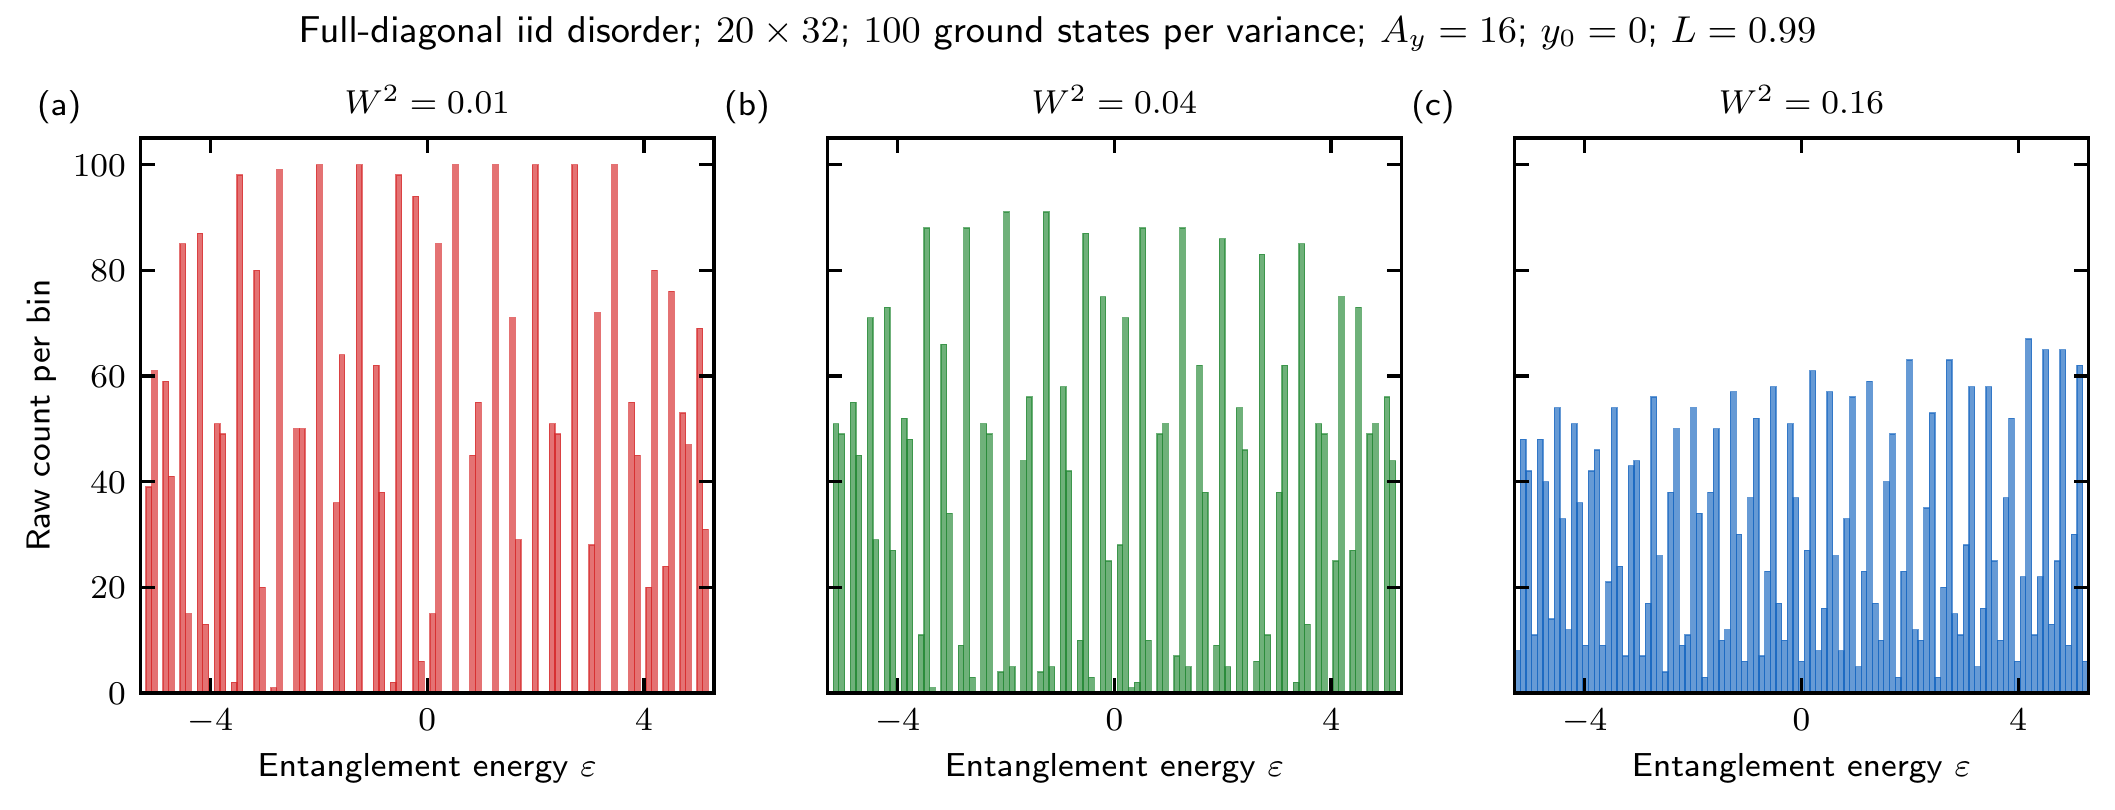

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
BINS=101
assert BINS%2==1
edges=np.linspace(-E,E,BINS+1)
counts={};densities={};hist_rows=[]
for variance in [0.]+VARIANCES:
    a=clean_energy if variance==0 else energy[variance]
    n,_=np.histogram(a,edges)
    rho=n/(len(a)*np.diff(edges))
    assert n.sum()==len(a) and np.isclose(np.dot(rho,np.diff(edges)),1,rtol=0,atol=1e-14)
    counts[variance]=n;densities[variance]=rho
    for j in range(BINS):
        hist_rows.append({'disorder_variance':variance,'left':edges[j],'right':edges[j+1],
                         'count':int(n[j]),'density':float(rho[j])})
pd.DataFrame(hist_rows).to_csv(OUT/'histograms.csv',index=False)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],
 'font.size':8,'axes.labelsize':8,'axes.titlesize':8,'xtick.labelsize':8,'ytick.labelsize':8,
 'text.usetex':True,'pdf.fonttype':42,'xtick.direction':'in','ytick.direction':'in'})
fig,axes=plt.subplots(1,3,figsize=(7.05,2.7),sharex=True,sharey=True)
colors=['#d62728','#228833','#1565c0']
for ax,variance,color,letter in zip(axes,VARIANCES,colors,['(a)','(b)','(c)']):
    ax.bar(edges[:-1],counts[variance],width=np.diff(edges),align='edge',
           color=color,alpha=.65,edgecolor=color,linewidth=.3)
    ax.set(title=rf'$W^2={variance:g}$',xlabel=r'Entanglement energy $\varepsilon$',
           xlim=(-E,E),xticks=[-4,0,4])
    ax.tick_params(top=True,right=True)
    ax.text(-.18,1.04,letter,transform=ax.transAxes,fontweight='bold')
axes[0].set_ylabel('Raw count per bin')
fig.suptitle(r'Full-diagonal iid disorder; $20\times32$; $100$ ground states per variance; $A_y=16$; $y_0=0$; $L=0.99$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'disordered_entanglement_energy_counts.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'disordered_entanglement_energy_counts.pdf'),str(OUT/'disordered_entanglement_energy_counts')],check=True)
display(Image(filename=str(OUT/'disordered_entanglement_energy_counts.png'),width=1050))

## Normalized comparison with the clean ground state
Each panel is normalized separately to unit area within the selected window. The clean panel contains one state; the disordered panels each contain 100.

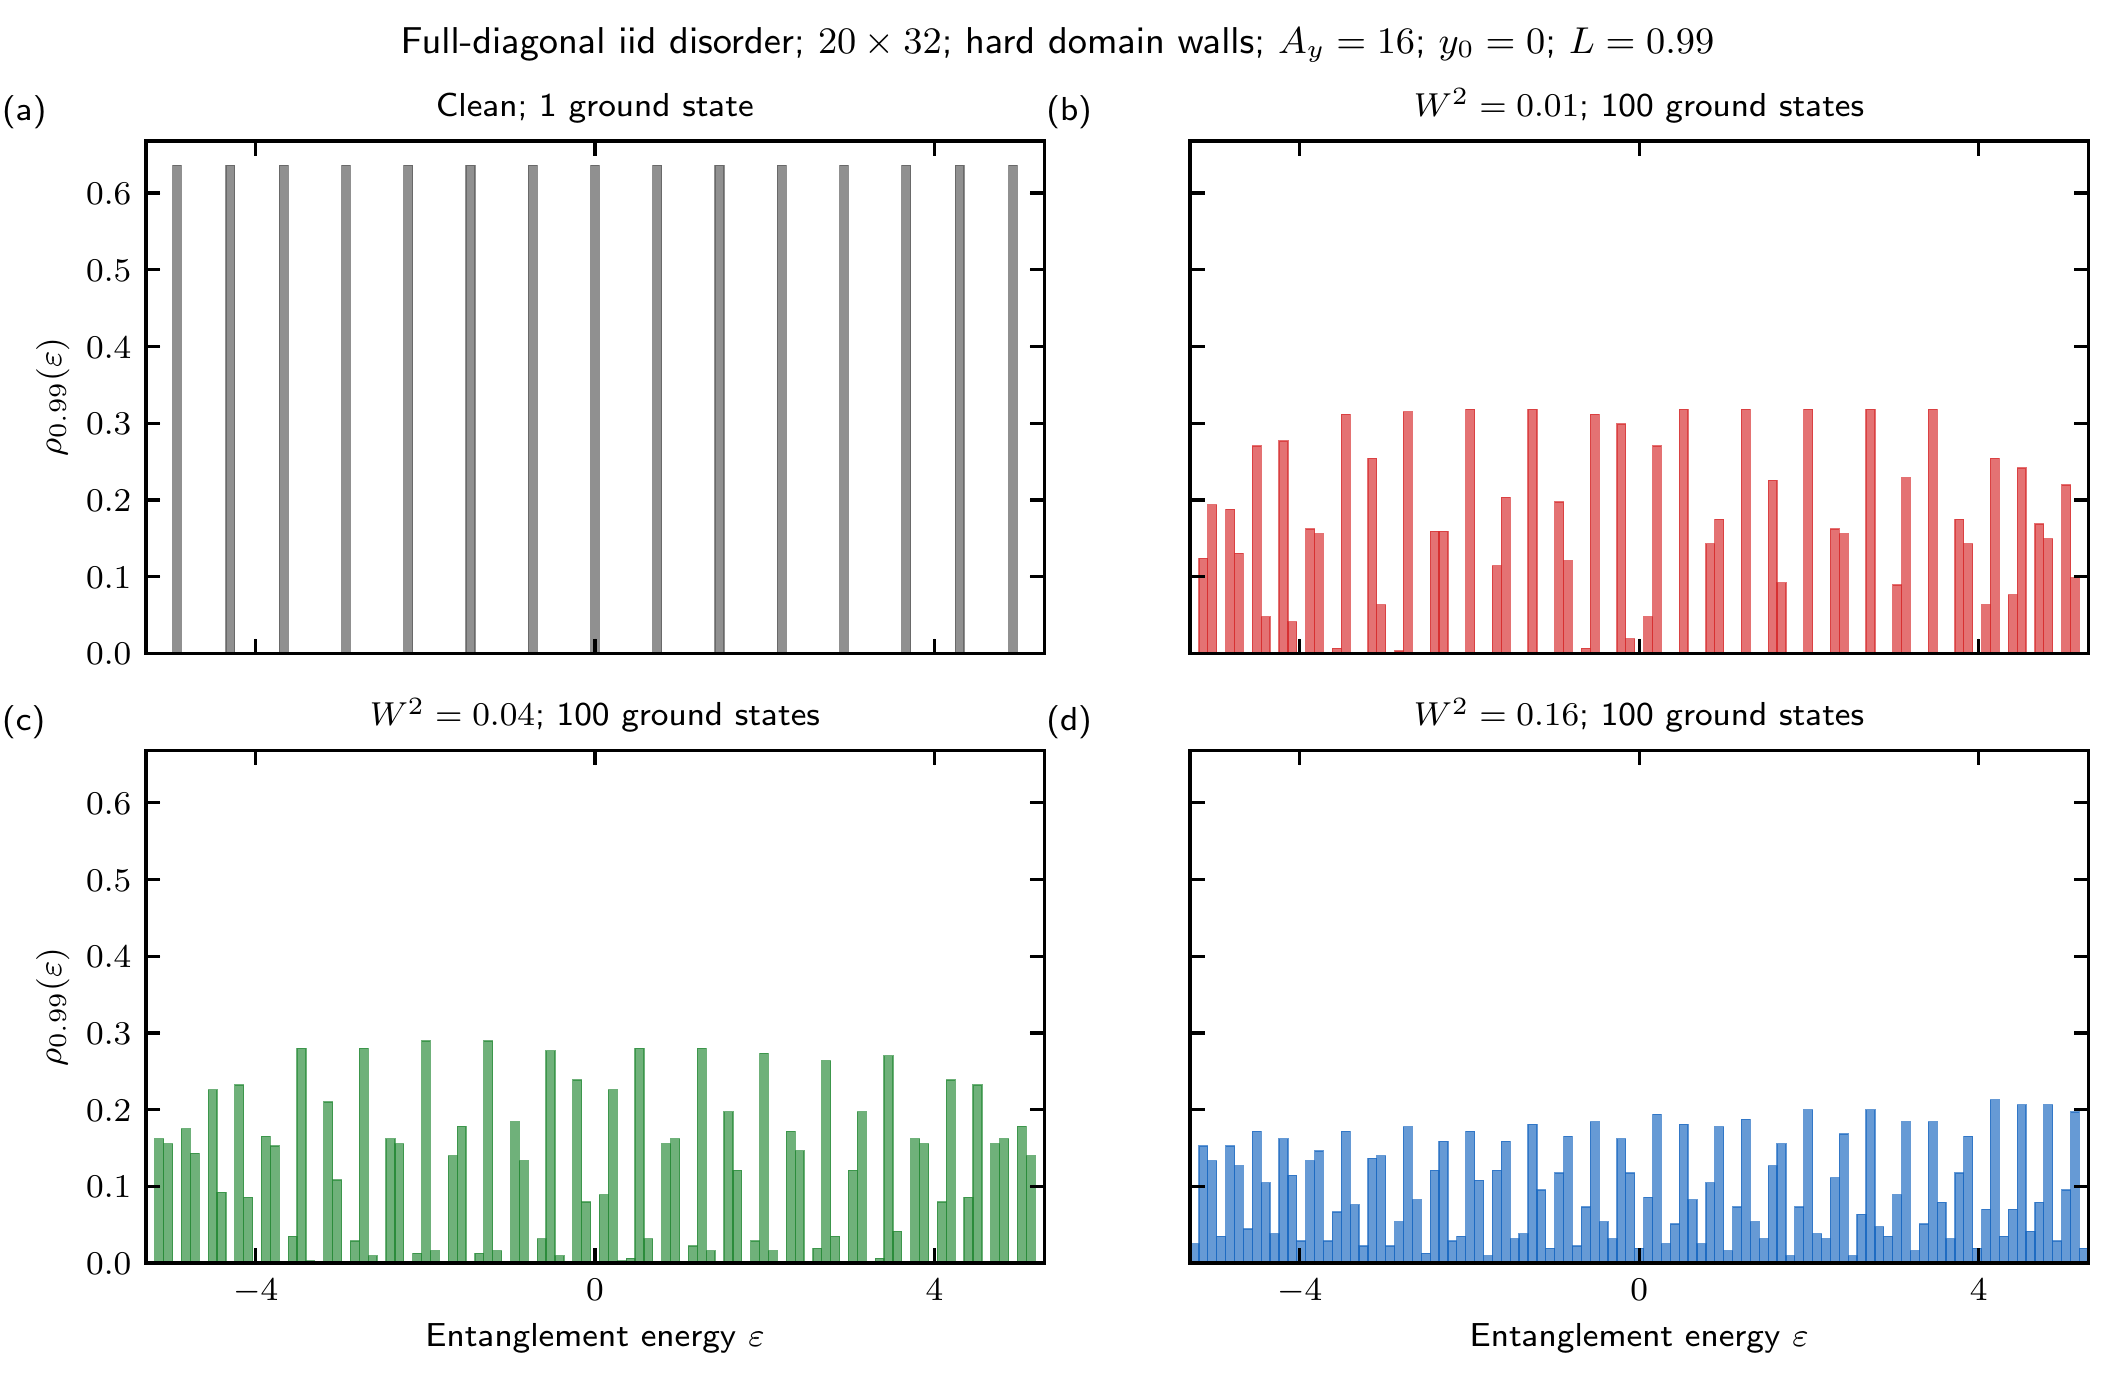

In [5]:
fig,axes=plt.subplots(2,2,figsize=(7.05,4.6),sharex=True,sharey=True)
for ax,variance,color,letter in zip(axes.flat,[0.]+VARIANCES,['#555555']+colors,['(a)','(b)','(c)','(d)']):
    ax.bar(edges[:-1],densities[variance],width=np.diff(edges),align='edge',
           color=color,alpha=.65,edgecolor=color,linewidth=.3)
    title='Clean; 1 ground state' if variance==0 else rf'$W^2={variance:g}$; 100 ground states'
    ax.set(title=title,xlim=(-E,E),xticks=[-4,0,4])
    ax.tick_params(top=True,right=True)
    ax.text(-.16,1.04,letter,transform=ax.transAxes,fontweight='bold')
for ax in axes[-1]:ax.set_xlabel(r'Entanglement energy $\varepsilon$')
for ax in axes[:,0]:ax.set_ylabel(r'$\rho_{0.99}(\varepsilon)$')
fig.suptitle(r'Full-diagonal iid disorder; $20\times32$; hard domain walls; $A_y=16$; $y_0=0$; $L=0.99$',fontsize=9)
fig.tight_layout(pad=.8)
fig.savefig(OUT/'clean_disordered_entanglement_energy_density.pdf')
plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'clean_disordered_entanglement_energy_density.pdf'),str(OUT/'clean_disordered_entanglement_energy_density')],check=True)
display(Image(filename=str(OUT/'clean_disordered_entanglement_energy_density.png'),width=1000))

## Diagnostics
All spectra are finite and within physical bounds; eigensystem orthogonality/residuals and global half filling were checked for every realization. The finite-window histogram conserves counts.

In [6]:
all_diag=[d['diagnostics'] for d in receipts]
diagnostics={'configuration':config,'bins':BINS,'realizations':len(receipts),
 'clean_reference_checks':json.loads((OUT/'input_provenance.json').read_text()),
 'max_eigen_residual':max(d['eigen_residual'] for d in all_diag),
 'max_orthogonality_error':max(d['orthogonality'] for d in all_diag),
 'minimum_half_filling_gap':min(d['half_filling_gap'] for d in all_diag),
 'raw_lambda_min':min(d['raw_lambda_min'] for d in all_diag),
 'raw_lambda_max':max(d['raw_lambda_max'] for d in all_diag),
 'full_space_crosscheck':next(d for d in all_diag if 'full_space_spectrum_crosscheck' in d),
 'summary':rows,'all_count_totals_verified':True,'all_density_integrals_verified':True}
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.Series({k:v for k,v in diagnostics.items() if isinstance(v,(int,float,bool))}))
print('Complete: 300 ground states; raw-count and normalized-density figures exported.')

bins                                   101
realizations                           300
max_eigen_residual                     0.0
max_orthogonality_error                0.0
minimum_half_filling_gap          0.000082
raw_lambda_min                        -1.0
raw_lambda_max                         1.0
all_count_totals_verified             True
all_density_integrals_verified        True
dtype: object

Complete: 300 ground states; raw-count and normalized-density figures exported.
